# Plotting Combinations of Categorical Variables

There are many ways to visualize relationships between variables.  
A good first step is to think about the **data types**:

- **Categorical vs categorical** → count plots, grouped bar charts, heatmaps
- **Continuous vs continuous** → scatter plots, line plots
- **Categorical vs continuous** → boxplots, violin plots, point plots

In this notebook, we will focus on **categorical vs categorical** visualizations:
- Grouped bar charts
- Multiple subplots
- Heatmaps using `pd.crosstab()` + `sns.heatmap()`

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Sample DataFrame

We will use a dataset of information collected on penguins, provided by Seaborn.

In [2]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Quick Look: Which Columns Are Categorical?

Before plotting, it helps to identify categorical variables (strings / categories).

In [3]:
penguins.info() #or dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


`species`, `island`, and `sex` have a data type of `object`, which indicates that they are categorical (probably have string labels).

## Grouped Bar Charts with `sns.catplot(..., kind="count")`

A **count plot** shows the number of rows in each category.

This is especially useful when:
- You have **two categorical variables**
- Each variable has a **small number of unique values** (roughly ≤ 5 is a good rule of thumb)

Here we'll use grouped bar charts to show the number of penguins (rows) of each species that are located on each island. We'll use the color of the bar to represent the island, while different values of species will have separate ticks on the x-axis.

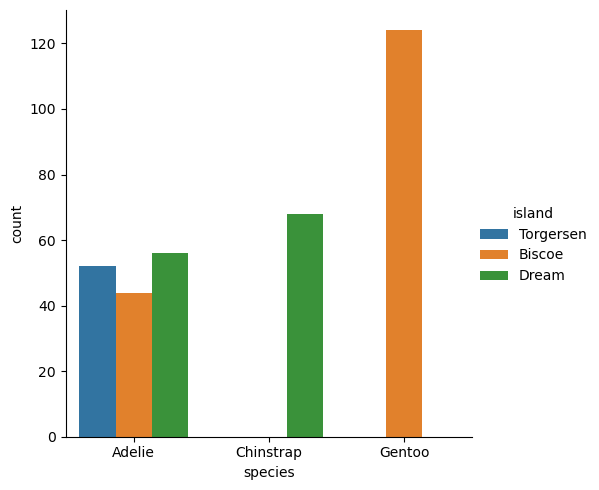

In [4]:
sns.catplot(data=penguins, x="species", hue="island", kind="count")
plt.show()

Note that we're missing some combinations! It looks like there all the chinstrap penguins are on Dream island, while Gentoo penguins are only on Biscoe.

## Facets (Subplots) to Represent Combinations of Categorical Variables

Another way to visualize combinations of categorical variables is by plotting separate subplots, sometimes called facets, for specific values of categorical variables.

Seaborn **figure-level** functions (like `catplot`, `displot`, `relplot`) can easily create facets with the `col` or `row` arguments.

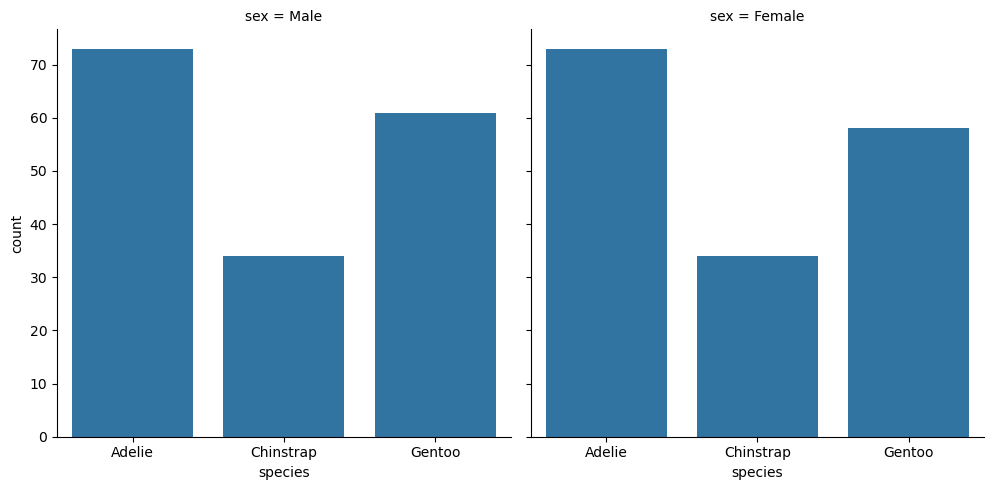

In [5]:
sns.catplot(data=penguins, x="species", col="sex", kind="count")
plt.show()

Facets allow a quick visualization of how the distribution (count) of penguins across species varies by male and female penguins in the dataset. We don't see much variation in the representation between these two genders! It appears that there are slighly more Gentoo male penguins than Gentoo female penguins, but other numbers look quite similar.

But we don't have to stop there! You can combine grouped bar charts and facets, as we do in the next example.

Here we visualize **3 categorical variables**:
- x-axis: `species`
- group (color): `island`
- facet column: `sex`

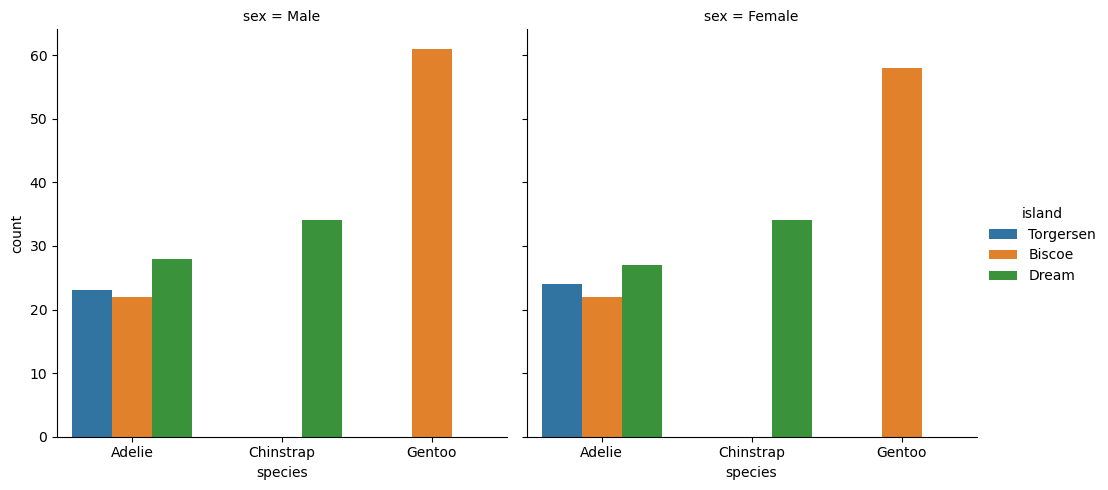

In [6]:
sns.catplot(data=penguins, x="species", hue="island", col="sex", kind="count")
plt.show()

Note that you can change which categorical variables are represented by different parts of the plot: facets, color, or ticks on the x-axis. Feel free to modify the code above to change the variables around and see different plots.

## Heatmaps for Categorical Relationships

When categorical variables have **many unique values**, grouped bar charts can get messy.

A heatmap can show:
- Categories on x and y axes
- **Counts encoded as color intensity** for quick visualization

We’ll build the counts table using `pd.crosstab()`. This count table will show how many rows have combinations of specific values in the dataset.

In [7]:
ct = pd.crosstab(penguins["species"], penguins["island"])
ct

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


### Heatmap of the Crosstab
Seaborn has a handy `heatmap` function that easily plots a heatmap from a crosstab table.

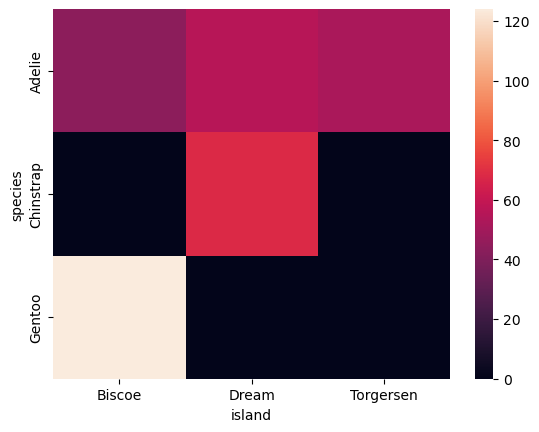

In [8]:
sns.heatmap(ct)
plt.show()

It's often useful to see the counts for each tile within the heatmap. We can pass `annot=True` to display that.

Other useful values to know (documentation [here](https://seaborn.pydata.org/generated/seaborn.heatmap.html)):
- `fmt="d"` ensures values print as integers
- `cbar=False` hides the color bar (optional)

Note that you can also run `fix, ax = plt.subplots()` and pass `ax` to the `ax` argument of `heatmap` to set and control options within the underlying Matplotlib Axes object.

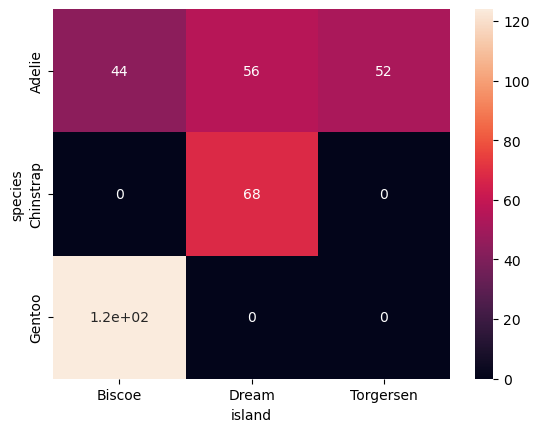

In [9]:
sns.heatmap(ct, annot=True)
plt.show()

## Practice Exercises

1. Create a grouped count plot showing `sex` on the x-axis and `species` as the hue.

2. Create a annotated heatmap of counts for `sex` vs `island`.  

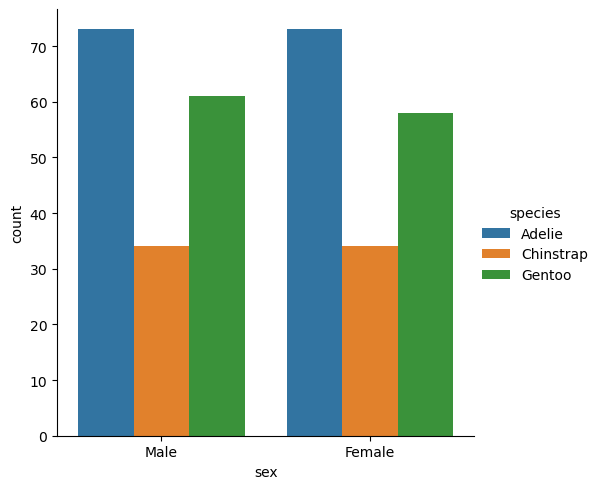

In [10]:
# 1
sns.catplot(data=penguins, x="sex", hue="species", kind="count")
plt.show()

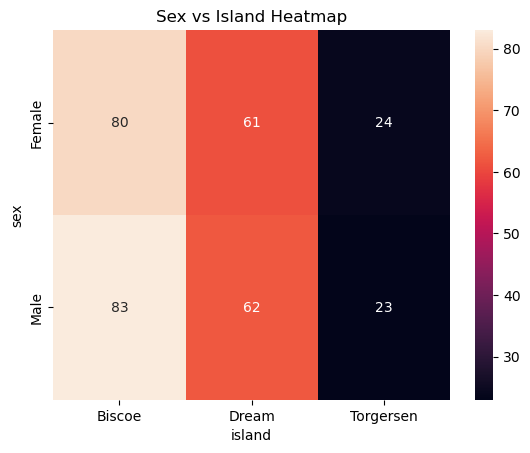

In [14]:
# 2
ct = pd.crosstab(penguins["sex"], penguins["island"])
sns.heatmap(ct, annot=True)
plt.title("Sex vs Island Heatmap")
plt.show()